# Sleep Debt Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/bedtime_screentime_sleep_debt.csv')

In [3]:
df.head()

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   str    
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   str    
 3   occupation_type           8500 non-null   str    
 4   chronotype                8500 non-null   str    
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   str    
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_sleep_pct      

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,8500.0,34.355647,11.584259,18.0,25.00,32.00,42.00,65.0
bedtime_phone_minutes,8500.0,59.250000,36.931991,1.0,31.00,51.00,79.00,180.0
screen_brightness_pct,8500.0,55.153882,19.850550,10.0,42.00,55.00,69.00,100.0
blue_light_filter_active,8500.0,0.467765,0.498989,0.0,0.00,0.00,1.00,1.0
caffeine_post_5pm_mg,8500.0,33.222471,51.935645,0.0,0.00,0.00,55.00,250.0
physical_activity_min,8500.0,35.701412,20.819390,0.0,21.00,35.00,50.00,112.0
sleep_latency_min,8500.0,40.671471,17.444914,6.0,28.20,37.60,49.70,123.3
total_sleep_hours,8500.0,6.266209,1.446258,3.2,5.24,6.33,7.35,9.8
deep_sleep_pct,8500.0,21.735741,3.069377,8.1,19.70,21.90,23.90,28.0
rem_sleep_pct,8500.0,19.105859,2.546459,9.6,17.40,19.10,20.80,27.0


In [6]:
df.describe(include='str').T

,count,unique,top,freq
user_id,8500,8500,USR-00001,1
gender,8500,3,Female,4347
occupation_type,8500,5,Corporate 9-to-5,2838
chronotype,8500,3,Intermediate,3880
primary_bedtime_app,8500,6,TikTok / Reels,2198
sleep_debt_category,8500,4,Moderate Debt,4462


In [7]:
df['gender'] = df['gender'].astype('category')

In [8]:
df['occupation_type'] = df['occupation_type'].astype('category')

In [9]:
df['chronotype'].unique()

<StringArray>
['Intermediate', 'Night Owl', 'Morning Lark']
Length: 3, dtype: str

In [10]:
df['chronotype'] = pd.Categorical(df['chronotype'], categories=['Morning Lark', 'Intermediate', 'Night Owl'], ordered=True)

In [11]:
df['primary_bedtime_app'] = df['primary_bedtime_app'].astype('category')

In [12]:
df['sleep_debt_category'].unique()

<StringArray>
['Severe Sleep Debt', 'Mild Deficit', 'Moderate Debt', 'Optimal Recovery']
Length: 4, dtype: str

In [13]:
df['sleep_debt_category'] = pd.Categorical(df['sleep_debt_category'], categories=['Optimal Recovery', 'Mild Deficit', 'Moderate Debt', 'Severe Sleep Debt'], ordered=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   user_id                   8500 non-null   str     
 1   age                       8500 non-null   int64   
 2   gender                    8500 non-null   category
 3   occupation_type           8500 non-null   category
 4   chronotype                8500 non-null   category
 5   bedtime_phone_minutes     8500 non-null   int64   
 6   primary_bedtime_app       8500 non-null   category
 7   screen_brightness_pct     8500 non-null   int64   
 8   blue_light_filter_active  8500 non-null   int64   
 9   caffeine_post_5pm_mg      8500 non-null   int64   
 10  physical_activity_min     8500 non-null   int64   
 11  sleep_latency_min         8500 non-null   float64 
 12  total_sleep_hours         8500 non-null   float64 
 13  deep_sleep_pct            8500 non-null   float64 
 14  rem

In [15]:
# pd.crosstab(df['occupation_type'], df['sleep_debt_category'], normalize='index') * 100

In [16]:
target = 'total_sleep_hours'

## Relationship Analysis

### Age

<Axes: xlabel='age', ylabel='total_sleep_hours'>

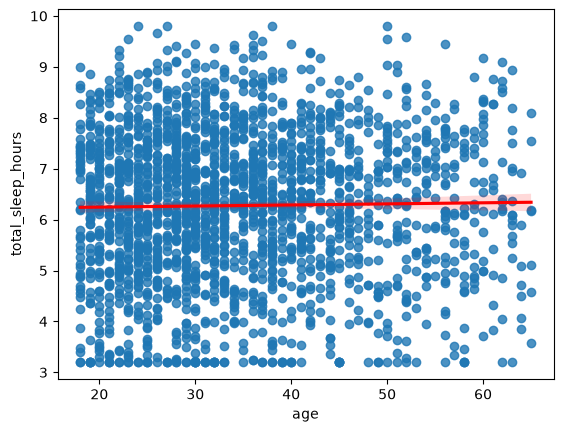

In [17]:
sns.regplot(data=df.sample(frac=0.25), x='age', y=target, line_kws={'color': 'red'})

In [18]:
np.corrcoef(df['age'], df[target])

array([[1.        , 0.01610819],
       [0.01610819, 1.        ]])

> The correlation coefficent and the regression plot is nearly 0, meaning there is almost no relationship between age and total_sleep_hours. To confirm, let's group age into bins and check the average total_sleep_hours.

In [19]:
df['age'].describe()

count    8500.000000
mean       34.355647
std        11.584259
min        18.000000
25%        25.000000
50%        32.000000
75%        42.000000
max        65.000000
Name: age, dtype: float64

In [20]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['age_bins'] = pd.cut(df['age'], bins=bins, labels=labels)

<Axes: xlabel='age_bins', ylabel='total_sleep_hours'>

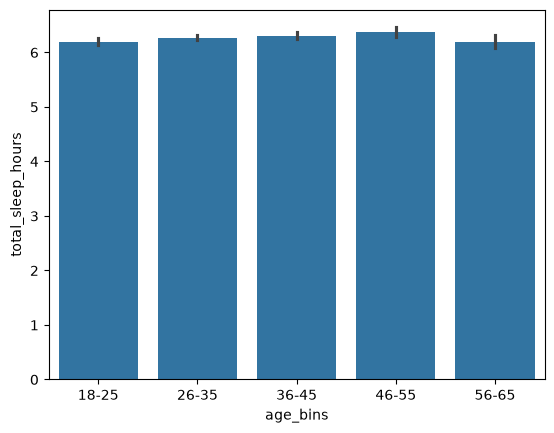

In [21]:
sns.barplot(data=df, x='age_bins', y=target)

<Axes: xlabel='total_sleep_hours', ylabel='Count'>

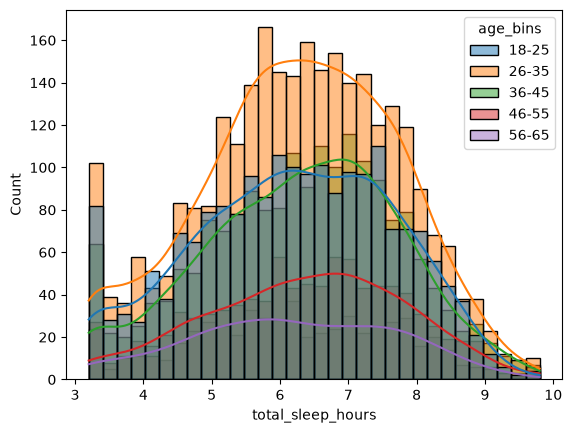

In [22]:
sns.histplot(data=df, x=target, hue='age_bins', kde=True)

> The above charts show that the average sleep hours are around the same for each age group, and the histogram show that the distribution is nearly normal for each age group as well, so age is not a defining factor for fewer hours of sleep.

### Gender

<Axes: xlabel='gender', ylabel='total_sleep_hours'>

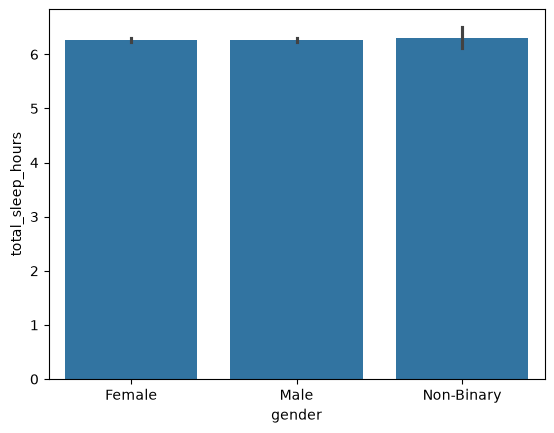

In [23]:
sns.barplot(data=df, x='gender', y=target)

<Axes: xlabel='total_sleep_hours', ylabel='Count'>

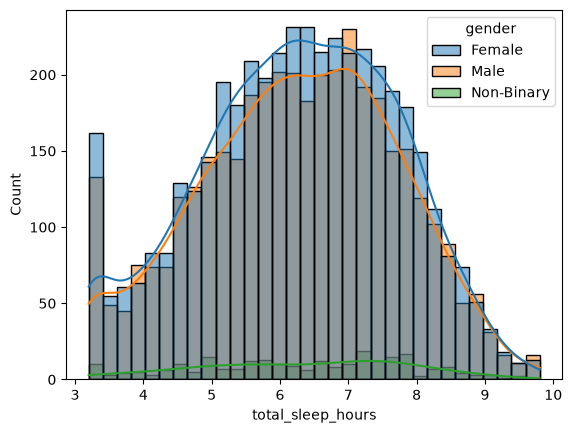

In [24]:
sns.histplot(data=df, x=target, hue='gender', kde=True)

> Similar to age, gender also does not seem to be a defining factor of fewer sleep hours. 

###  Occupation Type

In [25]:
df.groupby('occupation_type')[target].describe()

,count,mean,std,min,25%,50%,75%,max
occupation_type,,,,,,,,
Corporate 9-to-5,2838.0,6.430236,1.385625,3.2,5.4725,6.505,7.45,9.80
Freelance / Creative,901.0,6.376448,1.382207,3.2,5.3900,6.480,7.40,9.80
Healthcare / Shift Worker,997.0,5.015206,1.301399,3.2,3.8600,5.000,5.96,9.05
Remote Tech,2142.0,6.446793,1.379199,3.2,5.5100,6.505,7.48,9.80
Student,1622.0,6.448459,1.378401,3.2,5.4625,6.510,7.50,9.80


<Axes: xlabel='total_sleep_hours', ylabel='occupation_type'>

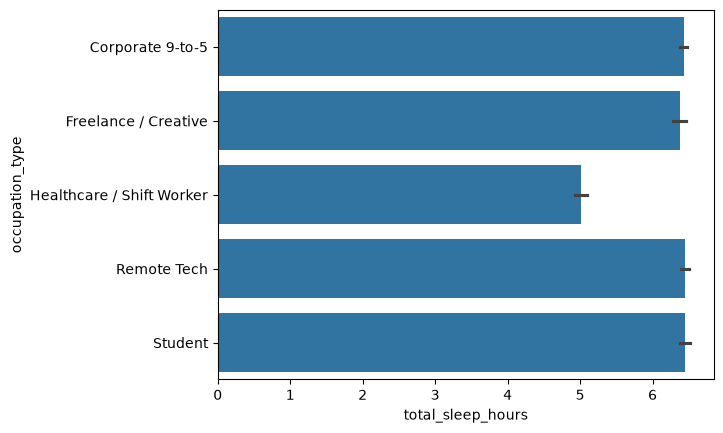

In [26]:
sns.barplot(data=df, y='occupation_type', x=target)

<Axes: xlabel='total_sleep_hours', ylabel='Count'>

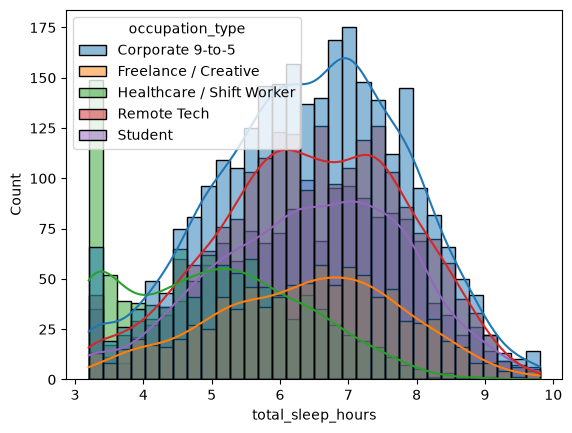

In [27]:
sns.histplot(data=df, x=target, hue='occupation_type', kde=True)

> The occupation type has shown something interesting. For the most part, the jobs all have similar average sleep (6+ hours), but healthcare/shift worker, the average is only 5 hours (approximately).
>
> Looking at the histogram, the distribution is around normal, except for healthcare/shift workers (green). This distribution if more right-skewed, peaking at around 5 hours, but there is also a spike around 3.5 hours. Healthcare workers do not get much sleep, which makes sense, given the nature of their work. While not completely definitive, it is a contributing factor. 

## Chronotype

In [28]:
df.groupby('chronotype')[target].mean()

chronotype
Morning Lark    7.381141
Intermediate    6.437936
Night Owl       5.011576
Name: total_sleep_hours, dtype: float64

<Axes: xlabel='total_sleep_hours', ylabel='chronotype'>

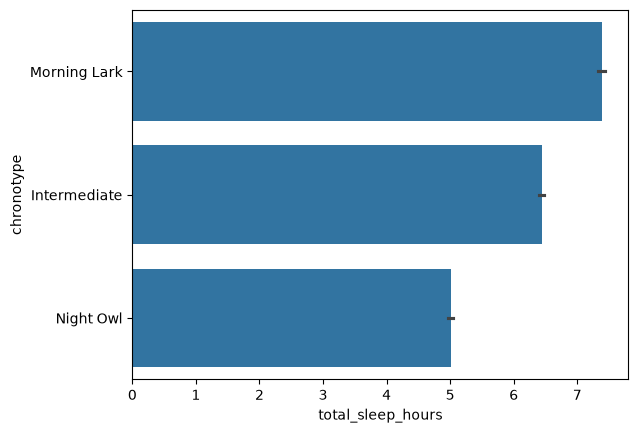

In [29]:
sns.barplot(data=df, x=target, y='chronotype')

<Axes: xlabel='total_sleep_hours', ylabel='Count'>

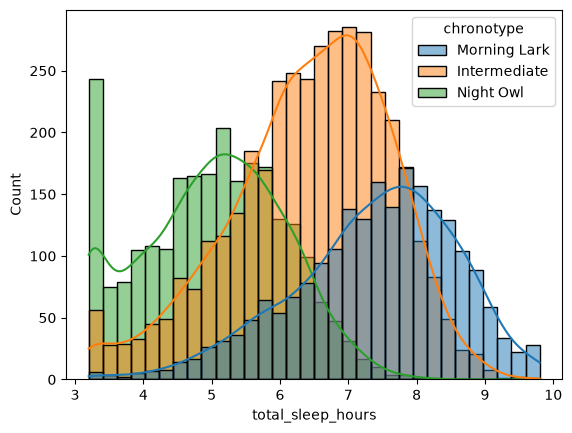

In [30]:
sns.histplot(data=df, x=target, hue='chronotype', kde=True)

> We can see that chronotype seems to be an excellent candidate for being a contributing factor. We can see that the chronotype of Intermediate (between being a morning lark and a night owl) is nearly normal, with the average sleep hours being around 6.5 hours. Meanwhile, Morning Larks tend to get more hours of sleep, averaging around 7.4, and night owls get the least, averaging 5 hours. For both night owls and morning larks, their distributions are close to normal, but are skewed a bit left and right, respectively. 

## Bedtime Phone Minutes

<Axes: xlabel='bedtime_phone_minutes', ylabel='Count'>

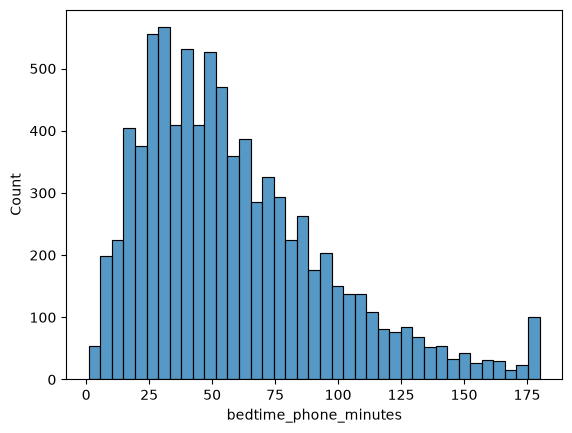

In [31]:
sns.histplot(data=df, x='bedtime_phone_minutes')

<Axes: xlabel='bedtime_phone_minutes', ylabel='total_sleep_hours'>

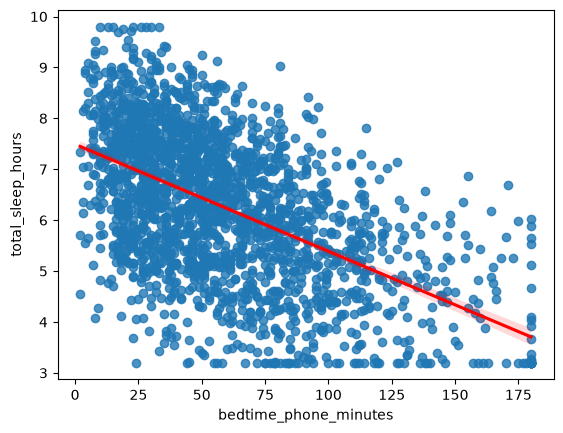

In [32]:
sns.regplot(data=df.sample(frac=0.25), x='bedtime_phone_minutes', y=target, line_kws={'color': 'red'})

In [33]:
df[['bedtime_phone_minutes', 'total_sleep_hours']].corr()

,bedtime_phone_minutes,total_sleep_hours
bedtime_phone_minutes,1.000000,-0.554407
total_sleep_hours,-0.554407,1.000000


> From the regplot and the correlation coefficent, there is a clear negative correlation between bedtime_phone_minutes and total_sleep_hours.
>
> The longer that someone spends on their phone after "going to bed", the less hours of sleep they get. It is possible that this could be due to needing to wake up at a certain time, but regardless, they are getting fewer hours of sleep since they are spending more time on their phone.
>
> This is a clear contributing factor for fewer sleep hours. 

## Primary Bedtime App

<Axes: xlabel='primary_bedtime_app', ylabel='total_sleep_hours'>

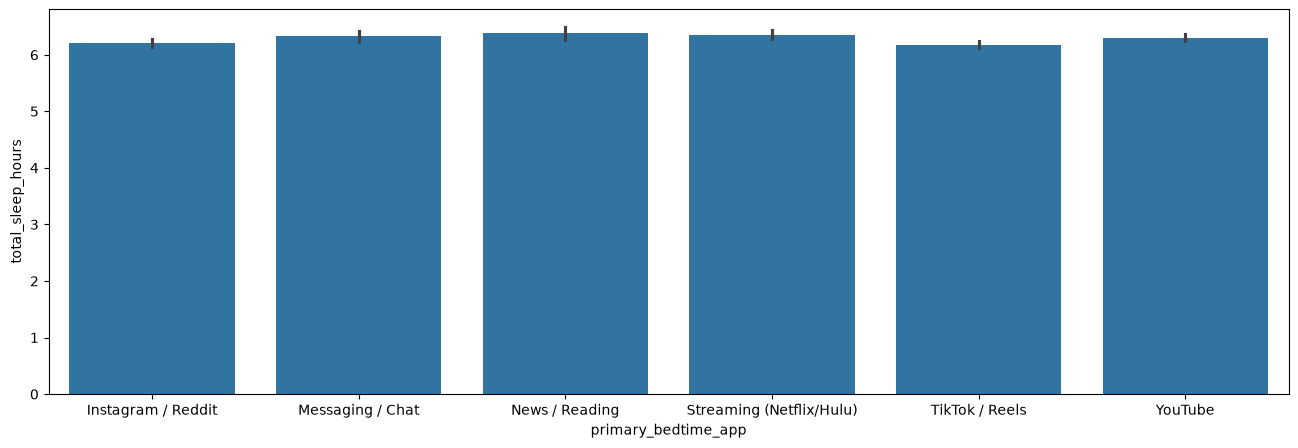

In [34]:
plt.figure(figsize=(16, 5))
sns.barplot(data=df, x='primary_bedtime_app', y=target)

<Axes: xlabel='total_sleep_hours', ylabel='primary_bedtime_app'>

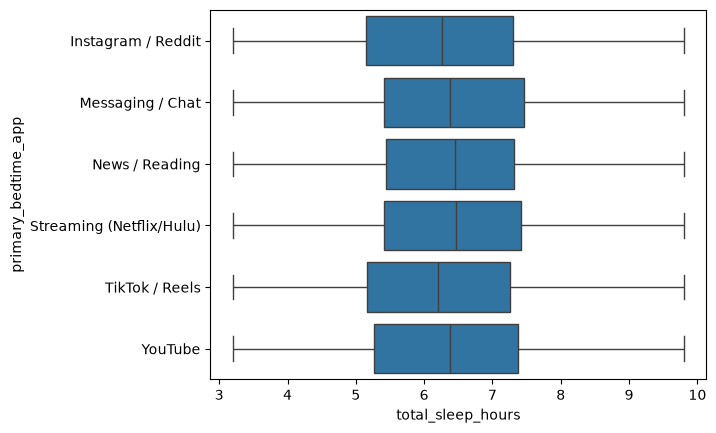

In [35]:
sns.boxplot(data=df, y='primary_bedtime_app', x=target)

In [36]:
df.groupby('primary_bedtime_app')[target].describe()

,count,mean,std,min,25%,50%,75%,max
primary_bedtime_app,,,,,,,,
Instagram / Reddit,1630.0,6.206141,1.445091,3.2,5.1500,6.260,7.3050,9.8
Messaging / Chat,847.0,6.326340,1.463944,3.2,5.4100,6.380,7.4600,9.8
News / Reading,596.0,6.379497,1.378246,3.2,5.4475,6.455,7.3150,9.8
Streaming (Netflix/Hulu),1301.0,6.355696,1.419351,3.2,5.4100,6.460,7.4200,9.8
TikTok / Reels,2198.0,6.173658,1.473944,3.2,5.1600,6.200,7.2600,9.8
YouTube,1928.0,6.300685,1.439281,3.2,5.2600,6.380,7.3725,9.8


> There does not seem to be any specific app that causes a user to get fewer hours of sleep. To be definitive, lets replot the previous feature (bedtime_phone_minutes) with a hue of the apps. 

<Axes: xlabel='bedtime_phone_minutes', ylabel='Count'>

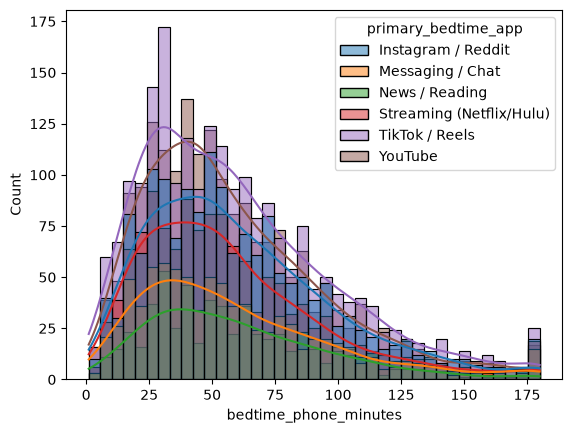

In [37]:
sns.histplot(data=df, x='bedtime_phone_minutes', hue='primary_bedtime_app', kde=True)

<Axes: xlabel='bedtime_phone_minutes', ylabel='primary_bedtime_app'>

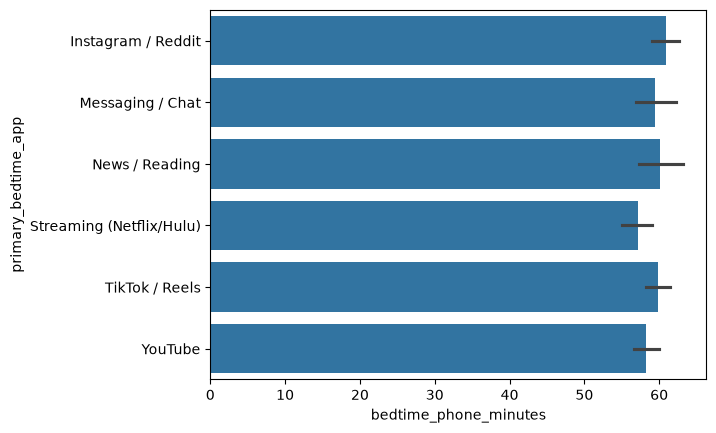

In [38]:
sns.barplot(data=df, y='primary_bedtime_app', x='bedtime_phone_minutes')

> The histogram with a hue for each app is intriguing, since we can see what are clearly the more popular apps (TikTOk and Youtube) vs the lesser popular apps, such as the news. However, in relation to total sleep hours, the result is the same, regardless of app.

## Screen Brightness Percent

<Axes: xlabel='screen_brightness_pct', ylabel='Count'>

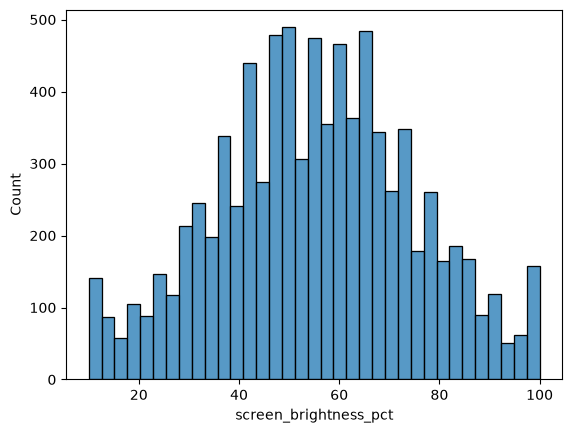

In [39]:
sns.histplot(data=df, x='screen_brightness_pct')

<Axes: xlabel='screen_brightness_pct', ylabel='total_sleep_hours'>

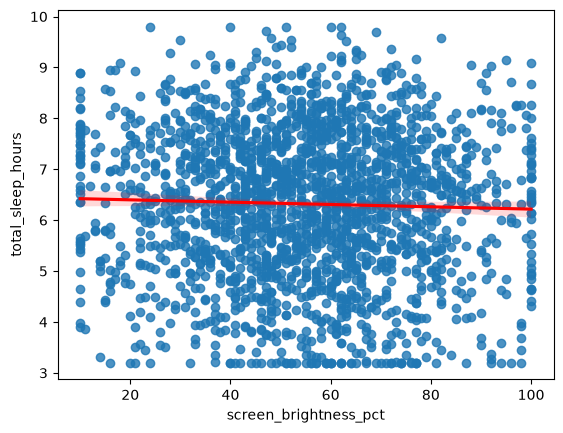

In [40]:
sns.regplot(data=df.sample(frac=0.25), x='screen_brightness_pct', y=target, line_kws={'color': 'red'})

In [41]:
df[['screen_brightness_pct', 'total_sleep_hours']].corr()

,screen_brightness_pct,total_sleep_hours
screen_brightness_pct,1.000000,-0.027445
total_sleep_hours,-0.027445,1.000000


> There does not seem to be any relationship between screen brightness and sleep hours. The correlation coefficent is nearly 0, indicating no correlation. 

## Blue Light Filter Active

<Axes: xlabel='blue_light_filter_active', ylabel='total_sleep_hours'>

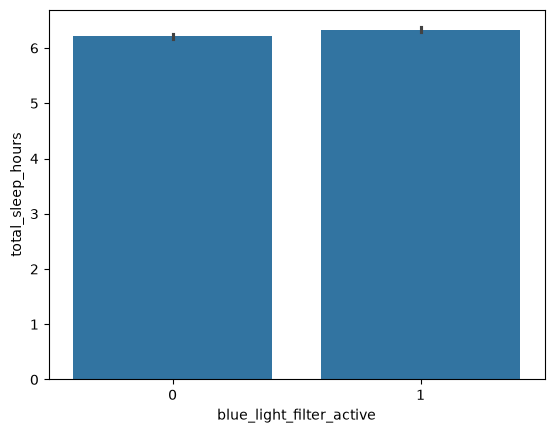

In [44]:
sns.barplot(data=df, x='blue_light_filter_active', y=target)

<Axes: xlabel='blue_light_filter_active', ylabel='total_sleep_hours'>

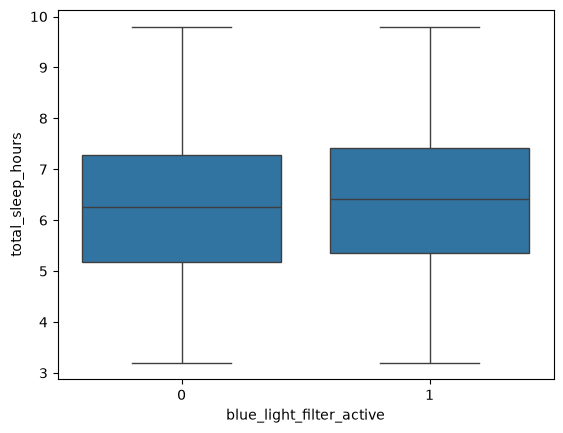

In [46]:
sns.boxplot(data=df, x='blue_light_filter_active', y=target)

In [45]:
df.groupby('blue_light_filter_active')[target].describe()

,count,mean,std,min,25%,50%,75%,max
blue_light_filter_active,,,,,,,,
0,4524.0,6.213970,1.45860,3.2,5.18,6.26,7.28,9.8
1,3976.0,6.325649,1.42995,3.2,5.35,6.41,7.41,9.8


> The blue light filter being active does not seem to make a difference in the total number of sleep hours, having nearly identical average sleep hours. 

## caffeine_post_5pm_mg

<Axes: xlabel='caffeine_post_5pm_mg', ylabel='Count'>

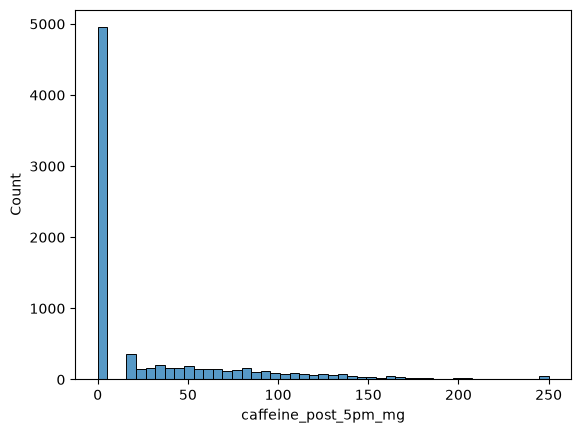

In [58]:
sns.histplot(data=df, x='caffeine_post_5pm_mg')

<Axes: xlabel='caffeine_post_5pm_mg', ylabel='total_sleep_hours'>

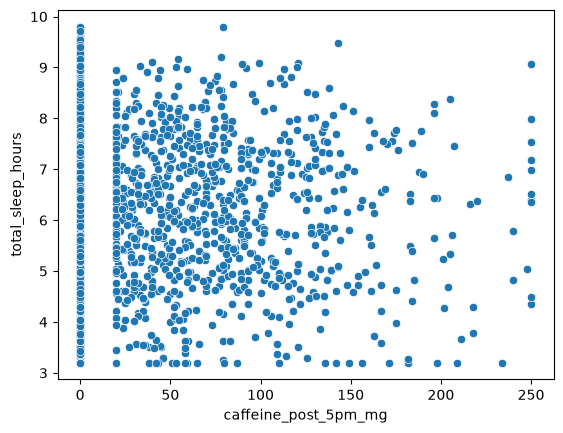

In [49]:
sns.scatterplot(data=df.sample(frac=0.25), x='caffeine_post_5pm_mg', y=target)

In [51]:
df[['caffeine_post_5pm_mg', target]].corr()

,caffeine_post_5pm_mg,total_sleep_hours
caffeine_post_5pm_mg,1.000000,-0.038262
total_sleep_hours,-0.038262,1.000000


>There is nearly no correation between drinking coffee (milligrams) after 5 PM and total sleep hours, which is surprising.
>
>This may indicate that some people are just used to drinking coffee late at night, and so doesn't cause any side effects.
>
>In any case, the histogram shows that the vast majority of people do not drink coffee after 5pm, shown by a large count of the data being 0 mg. 